In [1]:
# IMPORTS
from memo import memo, domain
from math import exp
import jax
import numpy as np
import jax.numpy as jnp
from jax.scipy.stats import beta as jax_beta
import matplotlib.pyplot as plt

# GLOBALS
INFO, ACTION = 0, 1
CAN, IMP, NULL = 0, 1, 2
ACT, PASS = 0, 1
goals = [INFO, ACTION]
U = [CAN, IMP, NULL]
R = [ACT, PASS]

# COSTS
c_can, c_imp = .1, .7 # utterance costs for speaker

mu_vals = np.linspace(0.001, .999, 50)   # grid over ability
theta_vals = np.linspace(0.01, 0.99, 20) # threshold values
f_k = 10     # concentration of feasibility prior
alpha = 10   # softmax param

# CONTEXTS: single parameter f_ctx (common-ground feasibility)
contexts = {
    'benchpress 150': 0.10,
    'drive me home':  0.70,
    'call me later':  0.90,
    'pass the salt':  0.99,
}

In [2]:
## Primitives

# Goal prior: action goals presuppose feasibility.
# Given feasibility, max-entropy → P(action) = 0.5 * f_ctx
@jax.jit
def goal_prior(g, f_ctx):
    p_action = 0.5 * f_ctx
    return jnp.where(g == ACTION, p_action, 1 - p_action)

# Feasibility prior: Beta prior over mu, concentrated around f_ctx
def f_prior(mu, f_ctx):
    mu_c = jnp.clip(mu, .01, .99)
    return jax_beta.pdf(mu_c, f_ctx * f_k, (1 - f_ctx) * f_k)

# Information gain: MI between mu and the answer to "can you?" (mu > t)
@jax.jit
def discrete_entropy(probs):
    p_c = jnp.clip(probs, 1e-12, 1.0)
    return -jnp.sum(p_c * jnp.log(p_c))

@jax.jit
def info_gain(f_ctx, t):
    mu_arr = jnp.array(mu_vals)
    raw = jax_beta.pdf(jnp.clip(mu_arr, .01, .99), f_ctx * f_k, (1 - f_ctx) * f_k)
    pi_f = raw / jnp.sum(raw)
    p_y = jnp.where(mu_arr > t, 1.0, 0.0)
    p_yes_marg = jnp.sum(pi_f * p_y)
    p_no_marg = 1.0 - p_yes_marg
    post_yes = pi_f * p_y / jnp.clip(p_yes_marg, 1e-12)
    post_no = pi_f * (1 - p_y) / jnp.clip(p_no_marg, 1e-12)
    return discrete_entropy(pi_f) - p_yes_marg * discrete_entropy(post_yes) \
                                  - p_no_marg * discrete_entropy(post_no)

# Response: ACT entails YES (acting answers the ability question)
# EU(ACT) = can, EU(PASS) = 1 - P(g=action)
@jax.jit
def respond(mu, t, p_ga):
    """P(ACT | mu, t, goal posterior)."""
    can = jnp.where(mu > t, 1.0, 0.0)
    logits = alpha * jnp.array([can, 1.0 - p_ga])
    logits = logits - logits.max()
    p = jnp.exp(logits)
    return p[ACT] / p.sum()

def marginalize_response(f_ctx, p_ga):
    """P(ACT) marginalized over mu (Beta prior) and t (uniform)."""
    mu_arr = jnp.array(mu_vals)
    raw = jax_beta.pdf(jnp.clip(mu_arr, .01, .99), f_ctx * f_k, (1 - f_ctx) * f_k)
    w_mu = raw / jnp.sum(raw)
    total = 0.0
    for t in theta_vals:
        acts = jax.vmap(lambda mu: respond(mu, t, p_ga))(mu_arr)
        total += float(jnp.sum(w_mu * acts))
    return total / len(theta_vals)

print("IG by context (avg over theta):")
for label, f_ctx in contexts.items():
    igs = [float(info_gain(f_ctx, t)) for t in theta_vals]
    print(f"  {label:<18} f_ctx={f_ctx:.2f}  avg_IG={np.mean(igs):.4f}")

IG by context (avg over theta):
  benchpress 150     f_ctx=0.10  avg_IG=0.1505
  drive me home      f_ctx=0.70  avg_IG=0.2391
  call me later      f_ctx=0.90  avg_IG=0.1505
  pass the salt      f_ctx=0.99  avg_IG=0.0818


In [3]:
## S1 — speaker marginalizes over uncertainty about addressee's ability
# Speaker knows their goal g but not addressee's mu.
# given(mu, t) + wants/EU → softmax of expected utility.
u_label = {CAN: 'can', IMP: 'imp', NULL: 'null'}
goal_label = {INFO: 'info', ACTION: 'action'}

@jax.jit
def eu_s1(u, g, mu, t, f_ctx):
    comply = jnp.where(mu > t, 1.0, 0.0)
    act = jnp.where(u == IMP, comply, 0.)
    info = jnp.where(u == CAN, info_gain(f_ctx, t), 0.)
    social = jnp.where(u == IMP, c_imp, 0.)
    question = jnp.where(u == CAN, c_can, 0.)
    return jnp.where(g == ACTION, act, info) - social - question

@memo
def S1[_u: U, _g: goals](f_ctx, alpha):
    speaker: knows(_g)
    speaker: given(mu in mu_vals, wpp=f_prior(mu, f_ctx))
    speaker: given(t in theta_vals, wpp=1)
    speaker: wants(payoff = eu_s1(u, _g, mu, t, f_ctx))
    speaker: chooses(u in U, wpp=exp(alpha * EU[payoff]))
    return Pr[speaker.u == _u]

s1_out = S1(f_ctx=0.5, alpha=alpha)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s1_out[ui, gi]), 3) for ui, u in enumerate(U)}
    print(f"S1(g={goal_label[g]}) = {probs}")

S1(g=info) = {'can': 0.653, 'imp': 0.0, 'null': 0.347}
S1(g=action) = {'can': 0.143, 'imp': 0.468, 'null': 0.389}


In [4]:
## A1 — addressee infers goal, then responds
# A1_goal references S1 directly — only 6 inner states (g × u).
# Response computed externally (addressee knows their own mu).

@memo
def A1_goal[_g: goals](f_ctx, alpha):
    a1: knows(_g)
    a1: thinks[
        spk: given(g in goals, wpp=goal_prior(g, f_ctx)),
        spk: chooses(u in U, wpp=S1[u, g](f_ctx, alpha))
    ]
    a1: observes_that[spk.u == 0]
    return a1[Pr[spk.g == _g]]

def a1_act(f_ctx):
    """A1's aggregate compliance: goal inference + response, marginalized."""
    p_ga = float(A1_goal(f_ctx=f_ctx, alpha=alpha)[ACTION])
    return marginalize_response(f_ctx, p_ga)

print("A1 by context:")
for label, f_ctx in contexts.items():
    g1 = float(A1_goal(f_ctx=f_ctx, alpha=alpha)[ACTION])
    p_a1 = a1_act(f_ctx)
    print(f"  {label:<18} f_ctx={f_ctx:.2f}  P(g=act)={g1:.3f}  P(act)={p_a1:.3f}")

A1 by context:
  benchpress 150     f_ctx=0.10  P(g=act)=0.025  P(act)=0.059
  drive me home      f_ctx=0.70  P(g=act)=0.076  P(act)=0.474
  call me later      f_ctx=0.90  P(g=act)=0.067  P(act)=0.592
  pass the salt      f_ctx=0.99  P(g=act)=0.064  P(act)=0.628


In [5]:
## S2 — speaker anticipates A1's aggregate compliance

@jax.jit
def eu_s2(u, g, mu, t, f_ctx, p_a1_do):
    """S2 utility: CAN+ACTION uses A1's aggregate compliance."""
    comply = jnp.where(mu > t, 1.0, 0.0)
    act_can = jnp.where(u == CAN, p_a1_do, 0.)
    act_imp = jnp.where(u == IMP, comply, 0.)
    act = jnp.where(u == CAN, act_can, act_imp)
    info = jnp.where(u == CAN, info_gain(f_ctx, t), 0.)
    social = jnp.where(u == IMP, c_imp, 0.)
    question = jnp.where(u == CAN, c_can, 0.)
    return jnp.where(g == ACTION, act, info) - social - question

@memo
def S2[_u: U, _g: goals](f_ctx, p_a1_do, alpha):
    speaker: knows(_g)
    speaker: given(mu in mu_vals, wpp=f_prior(mu, f_ctx))
    speaker: given(t in theta_vals, wpp=1)
    speaker: wants(payoff = eu_s2(u, _g, mu, t, f_ctx, p_a1_do))
    speaker: chooses(u in U, wpp=exp(alpha * EU[payoff]))
    return Pr[speaker.u == _u]

p_a1_mid = a1_act(0.5)
s2_out = S2(f_ctx=0.5, p_a1_do=p_a1_mid, alpha=alpha)
for gi, g in enumerate(goals):
    probs = {u_label[u]: round(float(s2_out[ui, gi]), 3) for ui, u in enumerate(U)}
    print(f"S2(g={goal_label[g]}) = {probs}")

S2(g=info) = {'can': 0.653, 'imp': 0.0, 'null': 0.347}
S2(g=action) = {'can': 0.618, 'imp': 0.321, 'null': 0.061}


In [6]:
## A2 — same structure as A1, but models S2

@memo
def A2_goal[_g: goals](f_ctx, p_a1_do, alpha):
    a2: knows(_g)
    a2: thinks[
        spk: given(g in goals, wpp=goal_prior(g, f_ctx)),
        spk: chooses(u in U, wpp=S2[u, g](f_ctx, p_a1_do, alpha))
    ]
    a2: observes_that[spk.u == 0]
    return a2[Pr[spk.g == _g]]

def a2_act(f_ctx):
    """A2's aggregate compliance."""
    p_a1 = a1_act(f_ctx)
    p_ga = float(A2_goal(f_ctx=f_ctx, p_a1_do=p_a1, alpha=alpha)[ACTION])
    return marginalize_response(f_ctx, p_ga)

print("A2 by context:")
for label, f_ctx in contexts.items():
    p_a1 = a1_act(f_ctx)
    g2 = float(A2_goal(f_ctx=f_ctx, p_a1_do=p_a1, alpha=alpha)[ACTION])
    p_a2 = a2_act(f_ctx)
    print(f"  {label:<18} f_ctx={f_ctx:.2f}  P(g=act)={g2:.3f}  P(act)={p_a2:.3f}")

A2 by context:
  benchpress 150     f_ctx=0.10  P(g=act)=0.037  P(act)=0.062
  drive me home      f_ctx=0.70  P(g=act)=0.400  P(act)=0.684
  call me later      f_ctx=0.90  P(g=act)=0.591  P(act)=0.894
  pass the salt      f_ctx=0.99  P(g=act)=0.693  P(act)=0.961


context            f_ctx  P(g=a|A1)  P(act|A1)  P(g=a|A2)  P(act|A2)
  benchpress 150      0.10      0.025      0.059      0.037      0.062
  drive me home       0.70      0.076      0.474      0.400      0.684
  call me later       0.90      0.067      0.592      0.591      0.894
  pass the salt       0.99      0.064      0.628      0.693      0.961

A1 goal mono:       False
A2 goal mono:       True
A1 compliance mono: True
A2 compliance mono: True


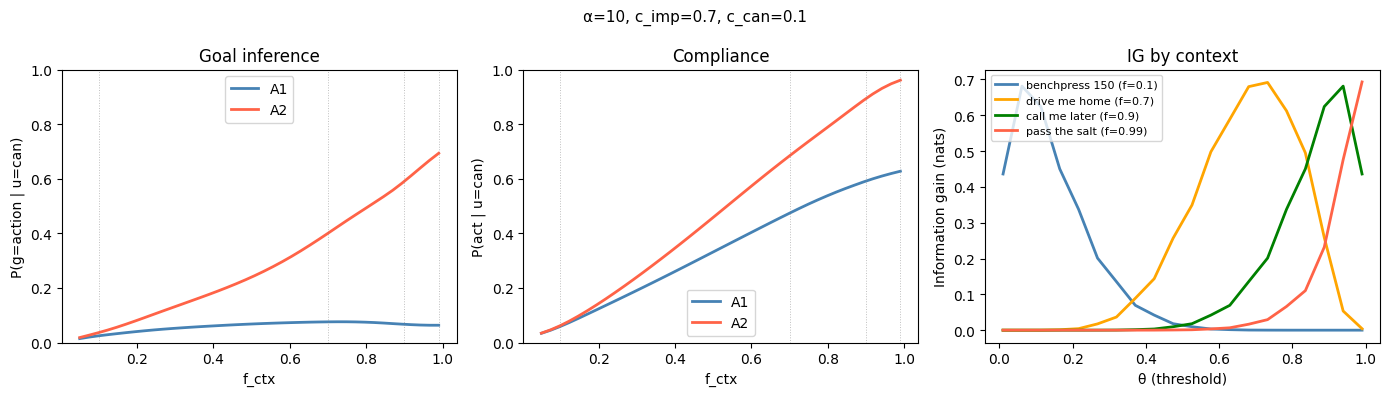

In [7]:
## plots: A1 vs A2

# Summary table
print(f"{'context':<18} {'f_ctx':>5} {'P(g=a|A1)':>10} {'P(act|A1)':>10} {'P(g=a|A2)':>10} {'P(act|A2)':>10}")
for label, f_ctx in contexts.items():
    p_a1 = a1_act(f_ctx)
    g1 = float(A1_goal(f_ctx=f_ctx, alpha=alpha)[ACTION])
    g2 = float(A2_goal(f_ctx=f_ctx, p_a1_do=p_a1, alpha=alpha)[ACTION])
    p_a2 = a2_act(f_ctx)
    print(f"  {label:<18} {f_ctx:>5.2f} {g1:>10.3f} {p_a1:>10.3f} {g2:>10.3f} {p_a2:>10.3f}")

# Monotonicity checks
ga1 = [float(A1_goal(f_ctx=f, alpha=alpha)[ACTION]) for f in contexts.values()]
ga2 = [float(A2_goal(f_ctx=f, p_a1_do=a1_act(f), alpha=alpha)[ACTION]) for f in contexts.values()]
va1 = [a1_act(f) for f in contexts.values()]
va2 = [a2_act(f) for f in contexts.values()]
print(f"\nA1 goal mono:       {all(a < b for a, b in zip(ga1, ga1[1:]))}")
print(f"A2 goal mono:       {all(a < b for a, b in zip(ga2, ga2[1:]))}")
print(f"A1 compliance mono: {all(a < b for a, b in zip(va1, va1[1:]))}")
print(f"A2 compliance mono: {all(a < b for a, b in zip(va2, va2[1:]))}")

# Sweep over f_ctx
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fs = np.linspace(0.05, 0.99, 40)

ax = axes[0]
a1_goals = [float(A1_goal(f_ctx=f, alpha=alpha)[ACTION]) for f in fs]
a2_goals = [float(A2_goal(f_ctx=f, p_a1_do=a1_act(f), alpha=alpha)[ACTION]) for f in fs]
ax.plot(fs, a1_goals, label='A1', color='steelblue', linewidth=2)
ax.plot(fs, a2_goals, label='A2', color='tomato', linewidth=2)
for label, f_ctx in contexts.items():
    ax.axvline(f_ctx, color='gray', ls=':', lw=0.7, alpha=0.5)
ax.set_xlabel('f_ctx'); ax.set_ylabel('P(g=action | u=can)')
ax.set_title('Goal inference'); ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
a1_acts = [a1_act(f) for f in fs]
a2_acts = [a2_act(f) for f in fs]
ax.plot(fs, a1_acts, label='A1', color='steelblue', linewidth=2)
ax.plot(fs, a2_acts, label='A2', color='tomato', linewidth=2)
for label, f_ctx in contexts.items():
    ax.axvline(f_ctx, color='gray', ls=':', lw=0.7, alpha=0.5)
ax.set_xlabel('f_ctx'); ax.set_ylabel('P(act | u=can)')
ax.set_title('Compliance'); ax.legend(); ax.set_ylim(0, 1)

ax = axes[2]
colors_ig = {'benchpress 150': 'steelblue', 'drive me home': 'orange',
             'call me later': 'green', 'pass the salt': 'tomato'}
for label, f_ctx in contexts.items():
    igs = [float(info_gain(f_ctx, t)) for t in theta_vals]
    ax.plot(theta_vals, igs, label=f'{label} (f={f_ctx})', linewidth=2, color=colors_ig[label])
ax.set_xlabel('θ (threshold)'); ax.set_ylabel('Information gain (nats)')
ax.set_title('IG by context'); ax.legend(fontsize=8)

plt.suptitle(f'α={alpha}, c_imp={c_imp}, c_can={c_can}', fontsize=11)
plt.tight_layout()
plt.show()

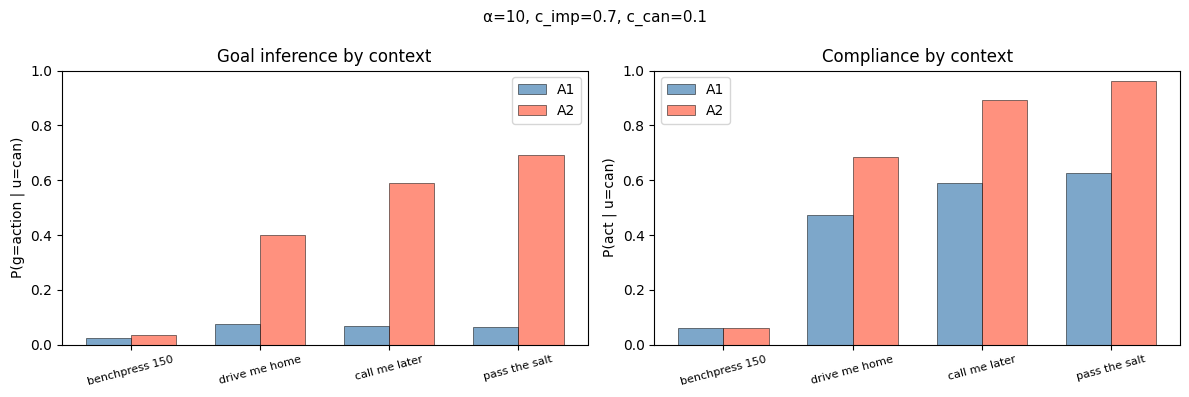

In [8]:
## plots: goal inference + compliance by context (bar chart)
labels = list(contexts.keys())
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(x - width/2, ga1, width, label='A1', color='steelblue', alpha=0.7, edgecolor='black', lw=0.5)
ax.bar(x + width/2, ga2, width, label='A2', color='tomato', alpha=0.7, edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=15)
ax.set_ylabel('P(g=action | u=can)')
ax.set_title('Goal inference by context')
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
ax.bar(x - width/2, va1, width, label='A1', color='steelblue', alpha=0.7, edgecolor='black', lw=0.5)
ax.bar(x + width/2, va2, width, label='A2', color='tomato', alpha=0.7, edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=15)
ax.set_ylabel('P(act | u=can)')
ax.set_title('Compliance by context')
ax.legend(); ax.set_ylim(0, 1)

plt.suptitle(f'α={alpha}, c_imp={c_imp}, c_can={c_can}', fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
## lab meeting heatmap grid (ability-only)
# a2_act(f) is 1D → tile across w rows → perfect columns
import os as _os

_N = 15
_fg = np.linspace(0.05, 0.99, _N)
_wg = np.linspace(0.05, 0.99, _N)
_out_dir = _os.path.join('..', 'results', 'model', 'whyask')
_grid_path = _os.path.join(_out_dir, 'fig1lm_grid_ability.npz')

if _os.path.exists(_grid_path):
    print('ability grid cached')
else:
    _Za_row = np.array([a2_act(float(f)) for f in _fg])
    _Za = np.tile(_Za_row, (_N, 1))  # shape (N_w, N_f) — perfect columns
    np.savez(_grid_path, Za=_Za, fg=_fg, wg=_wg)
    print(f'saved → {_grid_path}')


saved → ../results/model/whyask/fig1lm_grid_ability.npz
